#  PROJET FINAL — VISUALISATION DES DONNÉES UNIVERSITAIRES

## CONTEXTE

Ce projet est la suite directe du projet d'analyse réalisé avec **Pandas**.

Les analyses de base ont déjà été réalisées dans le projet Pandas : nettoyage, valeurs manquantes, jointures, calculs, moyennes, taux de réussite, analyses par filière/matière, présence, absences, retards, corrélations et classements.

**Ne refais donc pas tout le projet Pandas.**

Récupère le DataFrame final propre et utilise-le comme point de départ. L'objectif est maintenant de maîtriser **Matplotlib et Seaborn** pour transformer les résultats en représentations graphiques claires et les interpréter.

---

# PARTIE 0 — RÉCUPÉRATION DU DATAFRAME FINAL

### Travail
- Importer Pandas, Matplotlib et Seaborn.
- Charger le DataFrame final du projet Pandas.
- Afficher quelques lignes.
- Vérifier dimensions, colonnes et types.
- Vérifier les variables nécessaires aux graphiques.

### Questions
1. Combien de lignes possède le DataFrame ?
2. Combien de colonnes ?
3. Quelles variables seront utilisées ?
4. Quelles variables sont numériques ?
5. Quelles sont catégorielles ?
6. Existe-t-il encore des valeurs manquantes pouvant influencer les graphiques ?
7. Les données sont-elles prêtes pour la visualisation ?

---


In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:

data = pd.read_csv("../projet_pandas_universitaire/Données_collectés/Classement_General/Classement_Generale_par_ordre_de_merite.csv")
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent


In [3]:
data.tail()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
795,ETU1138,Lawson,Kodjo,17,F,Génie Civil,L1,5.59,Tres faible
796,ETU1357,Kouassi,Eyram,22,M,Génie Électrique,L1,5.21,Tres faible
797,ETU1746,Tchalla,Sena,21,M,IA & Big Data,L2,5.16,Tres faible
798,ETU1379,Adjei,Koffi,24,F,Génie Civil,L2,5.12,Tres faible
799,ETU1541,Mensah,Ama,25,M,Informatique & Systèmes,L3,4.33,Tres faible


In [4]:
# Les donnes sont deja pretes pour la visualisation


# PARTIE 1 — RÉPARTITION PAR FILIÈRE

### Graphiques
- Barplot des effectifs.
- Représentation des proportions.

### Questions
1. Quelle filière possède le plus d'étudiants ?
2. Quelle possède le moins d'étudiants ?
3. Les effectifs sont-ils équilibrés ?
4. Quelle proportion représente chaque filière ?
5. Le graphique confirme-t-il l'analyse Pandas ?
6. Quelle représentation est la plus lisible ?
7. Pourquoi ?

---

#### 1 et 2) Identification de la filiere posserdant le plus d'etudiant 

In [5]:
df = data["filiere"].value_counts()
df= df.reset_index()
df

,filiere,count
0,Informatique & Systèmes,200
1,IA & Big Data,189
2,Génie Électrique,150
3,Génie Civil,131
4,Logistique & Transport,130


C:\Users\dc\AppData\Local\Temp\ipykernel_4824\4256797949.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


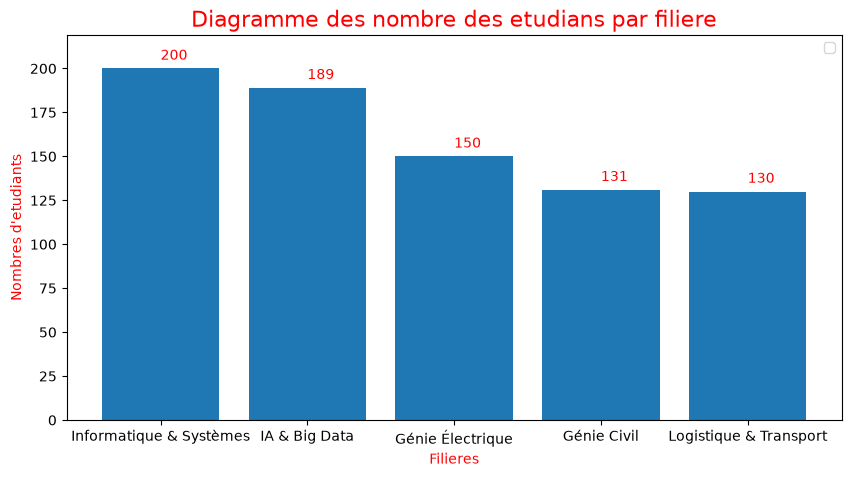

In [6]:
# Moi j'ai utiliser matplotlib pour la representation avec seaborn la syntaxe devrais :
# data["filiere"].value_counts().plot(kind = "bar")


plt.figure(figsize =(10, 5))
df_ordonne = df.sort_values("count", ascending = False)
plt.bar( height = df_ordonne["count"], x = df_ordonne["filiere"])
plt.title("Diagramme des nombre des etudians par filiere", size =16, c = "red")
plt.ylim(0, 219)
# plt.grid(axis = "y")
plt.xlabel("Filieres", size = 10, c= "red")
plt.ylabel("Nombres d'etudiants", size = 10, c ="red")

liste = df["count"].tolist()
for i in range(len(liste)):
    plt.text(i, liste[i]+5, liste[i], c="red")
    
plt.legend()

- la filiere Informatique et systemes es la filiere ayant plus de d'etudiant : ***200*** etudiants inscrits au total, et la filiere possedant le moins d'etudaint est la filiere ***Logistique & Transport*** au tolat ***130*** Etudiants inscrits

#### 3-) Les effectifs sont-ils équilibrés ?

In [7]:
proportion  = data["filiere"].value_counts(normalize = True)*(100)
proportion = round(proportion, 2).reset_index()
proportion 

,filiere,proportion
0,Informatique & Systèmes,25.00
1,IA & Big Data,23.62
2,Génie Électrique,18.75
3,Génie Civil,16.38
4,Logistique & Transport,16.25


Les effectifs sont un peut équilibrés entre les filières : chacune représente ses nombre d'etudiant plus proches du total des étudiants, 
soit une moins stricte.

#### 4-) Quelle proportion représente chaque filière ?

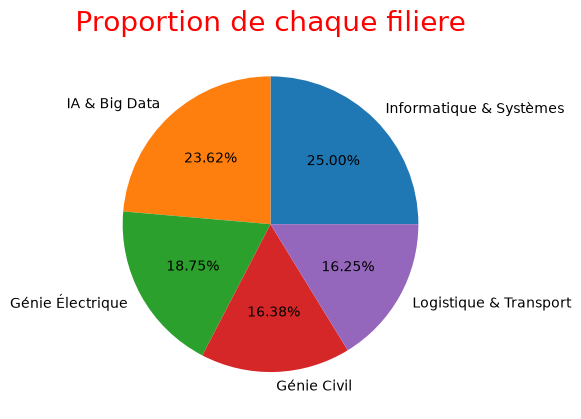

In [8]:
# Je vais tracer un diagramme circulaire pour represente la proportion de chaque filiere
plt.title("Proportion de chaque filiere", c = "red", size =20)
plt.pie( x = df["count"], labels = df["filiere"], autopct ="%.2f%%")
plt.show()

**5 - Reponse** : analyse graphique confirme belles et biens  les calcules avec pandas car les proportions on des legers ecarts

Selon moi La representation la plus lisible est le diagramme de bar , mais les deux representation sont tous visible, il faut noter que j'ai tester avec la fonction barplot , de seaborn je ne sais pas si c'est moi qui ne maitrise pas les bonnes pratiques , mais la representation n'est pas lisible.

# PARTIE 2 — RÉPARTITION PAR SEXE

### Graphiques
- Barplot.
- Représentation proportionnelle.
- Sexe par filière.

### Questions
1. Quelle catégorie est majoritaire ?
2. Quelle proportion représente-t-elle ?
3. La répartition est-elle équilibrée ?
4. La répartition varie-t-elle selon les filières ?
5. Quelle filière présente la plus grande différence ?
6. Quel graphique permet le mieux de comparer les filières ?
7. Que peux-tu conclure ?

---

#### 1-) determination de la categorie majoritaire

In [9]:
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent


In [10]:
cate = data.groupby("sexe")["sexe"].value_counts()
cate = cate.reset_index()
cate

,sexe,count
0,F,327
1,M,465
2,inconnue,8


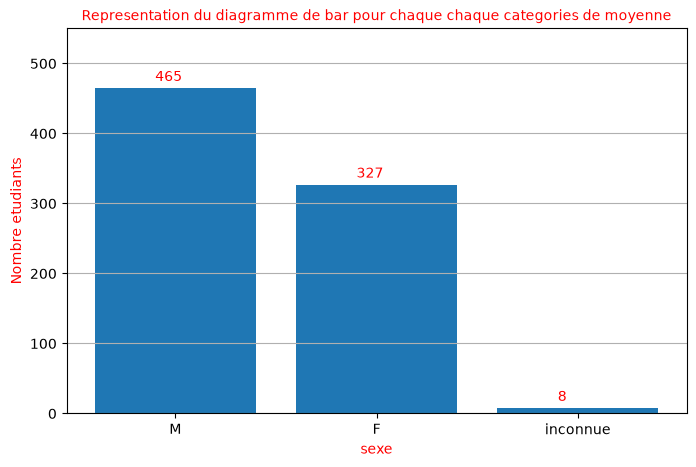

In [11]:
cate_Trier = cate.sort_values("count", ascending = False)
plt.figure(figsize =(8, 5))
plt.bar(x = cate_Trier["sexe"], height = cate_Trier["count"])
plt.xlabel("sexe", c="red") 
plt.ylabel("Nombre etudiants", c = "red")
plt.ylim(0, 550) # Limite du draphique
plt.title("Representation du diagramme de bar pour chaque chaque categories de moyenne", c = "red", size = 10)

liste = cate_Trier["count"].tolist()
for i in range(len(liste)):
    plt.text(i-0.1, liste[i]+10, liste[i], c = "red")

plt.grid(axis = "y")

 La categories Masculine est la categoire ***majoritaire*** avec ***465 etudiants***

<Axes: xlabel='sexe', ylabel='age'>

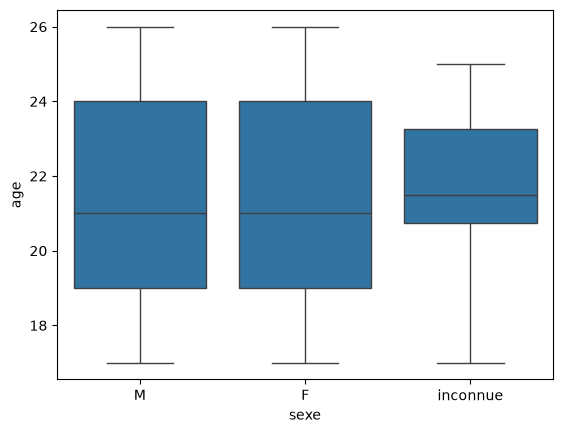

In [12]:
sns.boxplot(data = data , x ="sexe" , y = "age")

il y'a beaucoup d'etudiant avec des ages concentreer  plus de 21 ans , les ages max et nmin des sexe femini et masculin soint de 
(environ 17 ans a 26 ans ) avec des ages tres disperser beaucou p d'etudinst on des ages tre varie

#### 2- ) Quelle proportion représente-t-elle( la categorie majoritaire) ?

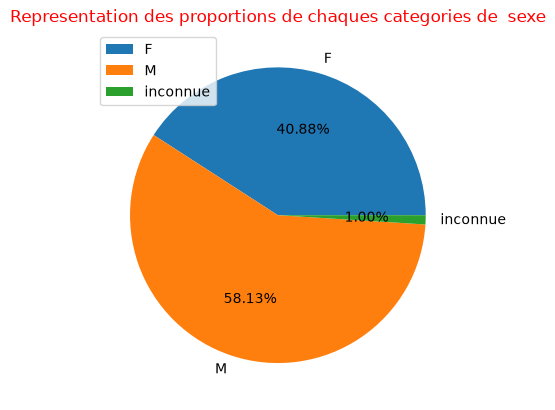

In [13]:
plt.pie(x = cate["count"], labels = cate["sexe"], autopct = "%.2f%%")
plt.title("Representation des proportions de chaques categories de  sexe", c = "red")
plt.legend()

 La repartion n'est pas equilibre car on as environ 7% d' ecart de proportion pour chaque categories de sexe et 1% de sexe non connues donc en 
definitive la repartion n'est pas equilibre

#### 3 - ) La répartition varie-t-elle selon les filières ?

In [14]:
# Pour l'instant il faut effectuer des analyses afin de le savoir ,
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent


In [15]:
# 1. Tableau des effectifs (Nombre de Hommes / Femmes par filière)
tableau_effectifs = pd.crosstab(data['filiere'], data['sexe'])
print("--- Effectifs par filière ---")
tableau_effectifs

--- Effectifs par filière ---


sexe,F,M,inconnue
filiere,,,
Génie Civil,59,71,1
Génie Électrique,63,85,2
IA & Big Data,71,115,3
Informatique & Systèmes,81,117,2
Logistique & Transport,53,77,0


In [16]:
# 2. Tableau en pourcentages par filière (Très important !)
# normalize='index' calcule le % de chaque sexe au sein de chaque filière
tableau_pourcentages = pd.crosstab(data['filiere'], data['sexe'], normalize="index") * 100
print("\n--- Pourcentages au sein de chaque filière (%) ---")
table= tableau_pourcentages.round(2)
table


--- Pourcentages au sein de chaque filière (%) ---


sexe,F,M,inconnue
filiere,,,
Génie Civil,45.04,54.20,0.76
Génie Électrique,42.00,56.67,1.33
IA & Big Data,37.57,60.85,1.59
Informatique & Systèmes,40.50,58.50,1.00
Logistique & Transport,40.77,59.23,0.00


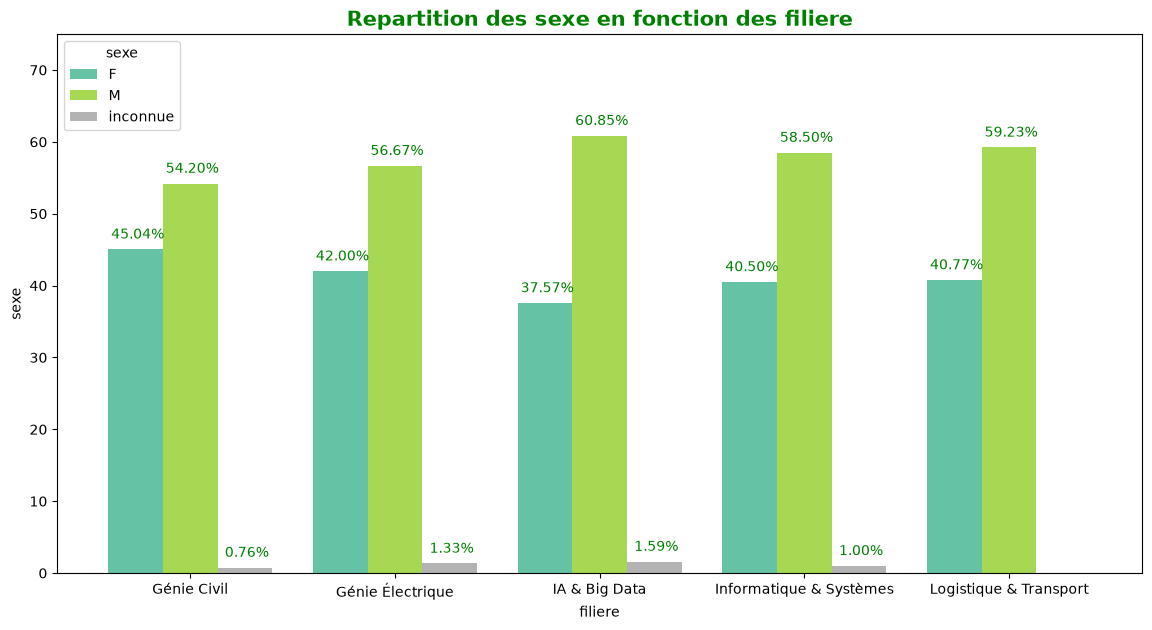

In [17]:
ax = table.plot(kind = "bar", cmap = "Set2", figsize = (14, 7), width = 0.8)
plt.title("Repartition des sexe en fonction des filiere", c= "green", fontweight = "bold", fontsize = 15)
plt.ylabel("sexe")
plt.xticks(rotation = 0)
plt.ylim(0, 75)

for container in ax.containers:
    for objet in container :
        taille = objet.get_height()
        if taille > 0:
            x = objet.get_x() + objet.get_width()/2
            y = taille + 2 # Petit decalage de 2% vers le haut
            plt.text(x, y, f"{taille : .2f}%", va = "center", ha = "center", color = "green")

#### Les categories varies en fonction des filieres

5. ) - La filiere presentant la plus  grande difference  :  ***Intellegicence Artificilelle et Bigdata (IA & BD)***

6_) - Selon moi c'est le ***diagramme de bar*** qui permet de comparer le mieux les filieres


# PARTIE 3 — DISTRIBUTION DES ÂGES

### Graphiques
- Histogramme.
- Histogramme + KDE.
- Boxplot.

### Questions
1. Quelle tranche d'âge est la plus représentée ?
2. La distribution est-elle concentrée ou dispersée ?
3. Est-elle symétrique ?
4. Existe-t-il des valeurs atypiques ?
5. Que montre le boxplot ?
6. Quel graphique représente le mieux la distribution ?
7. Quel graphique permet de détecter les valeurs atypiques ?
8. Quelle conclusion ?

---

#### 1- ) La tranche d'age la plus represente

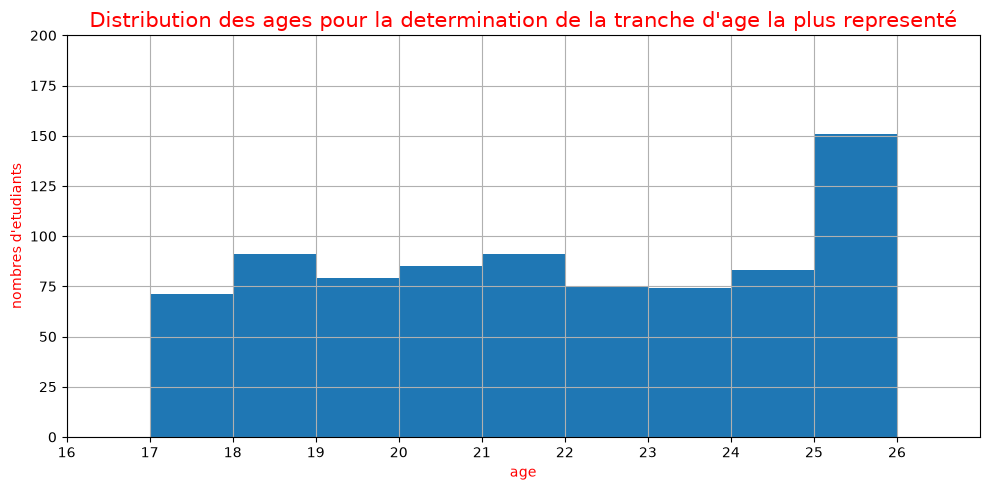

In [18]:
plt.figure(figsize = (10, 5))
plt.hist(data["age"],bins = 9)
plt.title("Distribution des ages pour la determination de la tranche d'age la plus representé", fontsize = 15 , c = "red")
plt.ylabel("nombres d'etudiants", c ="red")
plt.xlabel("age", c ="red")
#plt.yticks(ticks = np.arange(0, 100, 10))
plt.xticks(ticks = np.arange(0, 27, 1))
plt.ylim(0, 200)
plt.xlim(16, 27)
plt.tight_layout()
plt.grid()

##### La recherche de la tranche d'age la plus representer revient a determiner l'intervalle quui a la  bar le plus elevee : Dans le'histogramme.Dans notre cas cet **intervalle  est entre [25 ans , 26 ans]**

La distrubution est dispercer

<Axes: xlabel='age', ylabel='Count'>

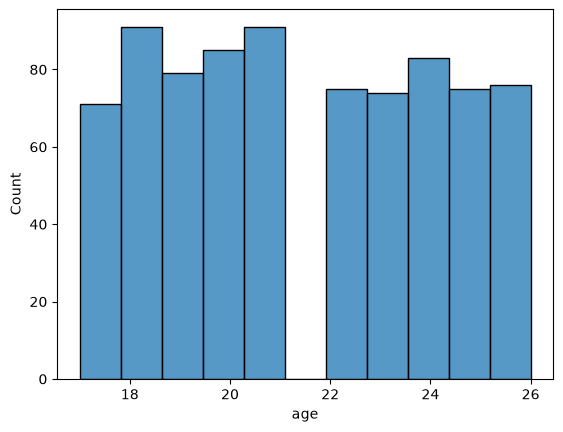

In [19]:
sns.histplot(data = data , x = "age")

#### 4-) Verification des valeurs atypique

C:\Users\dc\AppData\Local\Temp\ipykernel_4824\719717652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = "filiere" ,y = "age", palette = "Set2")


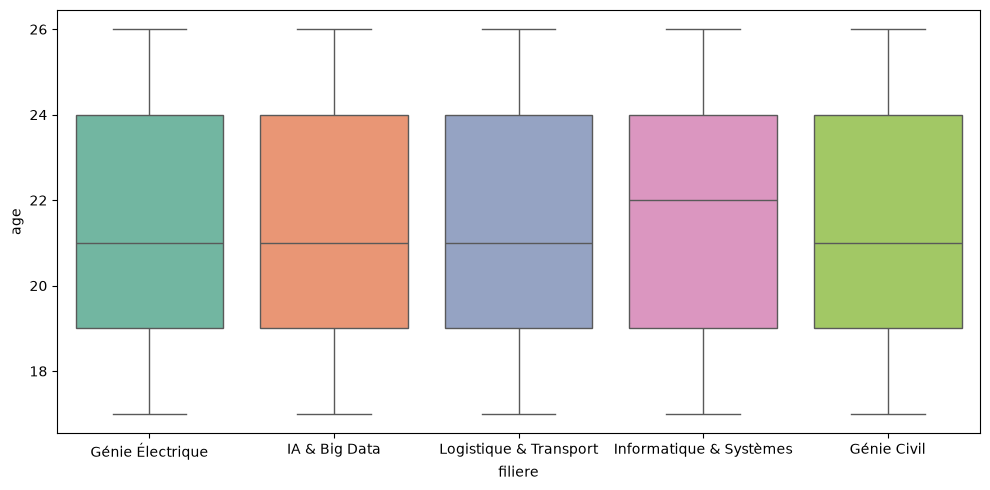

In [20]:
plt.figure(figsize = (10,5))
sns.boxplot(data = data, x = "filiere" ,y = "age", palette = "Set2")
plt.tight_layout()

Il n'existe pas de valeur atypique

# PARTIE 4 — DISTRIBUTION DES NOTES

### Graphiques
- Histogramme.
- Histogramme + KDE.
- Boxplot.

### Questions
1. Où se concentrent les notes ?
2. Quelle tranche est la plus fréquente ?
3. Les notes sont-elles plutôt faibles ou élevées ?
4. Combien de notes sont visuellement sous 10 ?
5. Existe-t-il beaucoup de notes élevées ?
6. Existe-t-il des valeurs atypiques ?
7. La distribution semble-t-elle normale ?
8. Quel graphique est le plus informatif ?
9. Le résultat confirme-t-il Pandas ?
10. Quelle conclusion sur le niveau général ?


#### 1 - )  Où se concentrent les notes ?

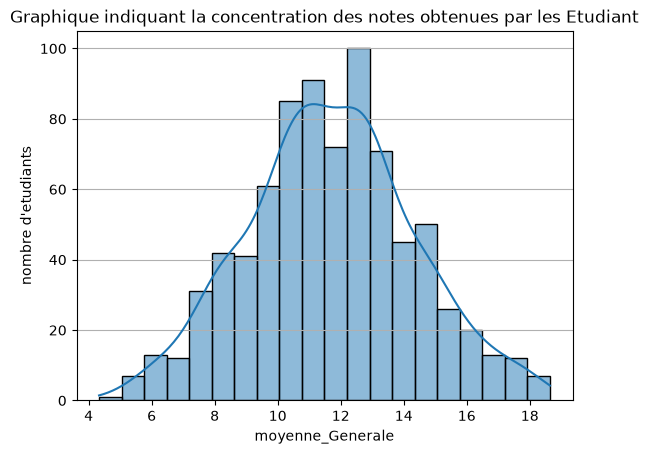

In [21]:
sns.histplot(data["moyenne_Generale"], kde = True)
plt.title("Graphique indiquant la concentration des notes obtenues par les Etudiant")
plt.ylabel("nombre d'etudiants")
# plt.ylim(0, 500)
# plt.yticks()
plt.grid(axis = "y")

In [22]:
# La tranche la plus frequence : [12, 13]

#### 6- ) Valeurs atypiques

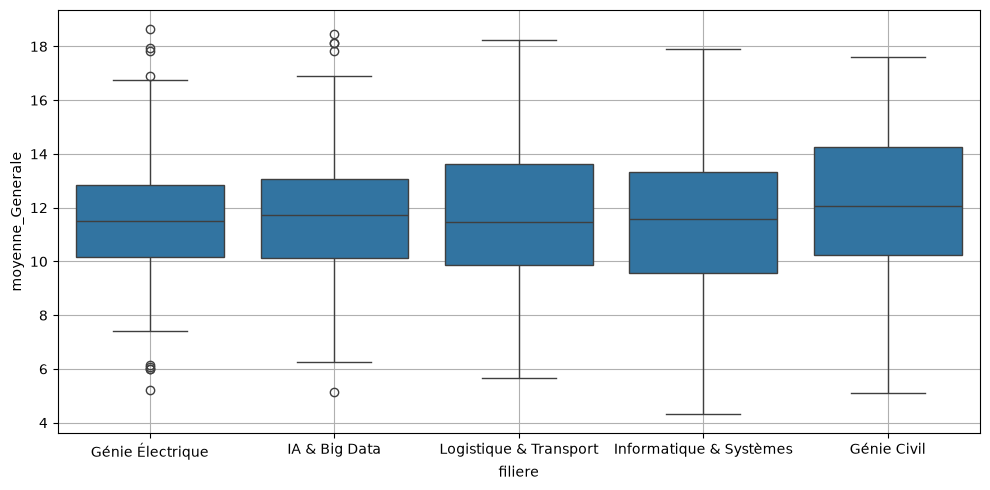

In [23]:
plt.figure(figsize = (10, 5))
sns.boxplot(data = data, x = "filiere", y = "moyenne_Generale")
# plt.yticks(ticks = np.arange(0, 20, 1))
plt.tight_layout()
plt.grid()


# PARTIE 5 RÉUSSITE ET ÉCHEC

Règle déjà utilisée dans Pandas : **note >= 10 = réussite ; note < 10 = échec**.

### Graphiques
- Barplot réussite/échec.
- Représentation proportionnelle.

### Questions
1. Quelle catégorie domine ?
2. Quel est le taux de réussite ?
3. Quel est le taux d'échec ?
4. L'écart est-il important ?
5. Le niveau paraît-il satisfaisant ?
6. Quel graphique est le plus efficace ?
7. Quelle conclusion ?

---

In [24]:
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent


#### 1-) La categories qui domine le plue (ECHEC / REUSSITES)

In [25]:
def categorie_notes(notes):
    if notes < 10:
        return "échec"
        
    else: 
        return "réussite"
        
data["categorie_notes"] = data.apply(
    lambda applique_ligne: categorie_notes(applique_ligne["moyenne_Generale"]), axis = 1)
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie,categorie_notes
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent,réussite
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent,réussite
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent,réussite
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent,réussite
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent,réussite


Text(0, 0.5, "Nombre d'etudiant")

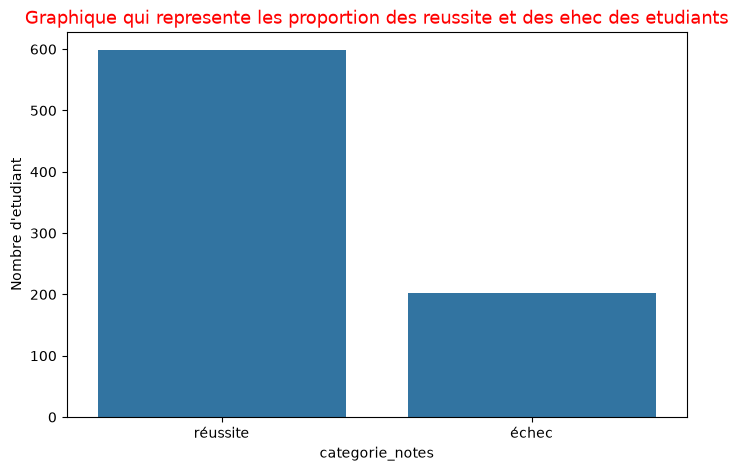

In [26]:
plt.figure(figsize = (8, 5))
sns.countplot(data = data, x="categorie_notes")
plt.title("Graphique qui represente les proportion des reussite et des ehec des etudiants",  size = 13, c = "red")
plt.ylabel("Nombre d'etudiant")

La categorie qui domine le plus est la categorie des ***reussite***

#### 2 -) Quel est le taux de réussite ?

In [27]:
#Utilisont un camenbert pour repondre a cette question 


In [28]:
taux_resultat = round(data["categorie_notes"].value_counts(normalize = True)*100, 2)
taux_resultat = taux_resultat.reset_index()
taux_resultat

,categorie_notes,proportion
0,réussite,74.75
1,échec,25.25


Text(0.5, 1.0, "Repartition du taux de reussite et d'echec")

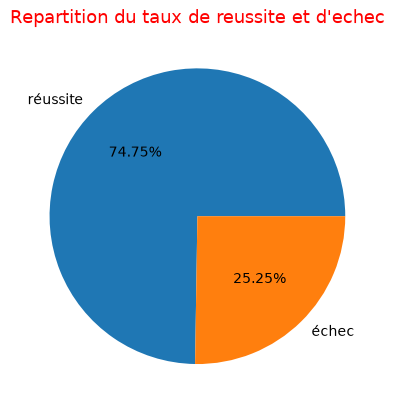

In [29]:
plt.pie(x = taux_resultat["proportion"], labels = taux_resultat["categorie_notes"], autopct = "%.2f%%")
plt.title("Repartition du taux de reussite et d'echec", c = "red", size = "13")

Oui l'ecart est vraiment important 


# PARTIE 6 — MOYENNE PAR FILIÈRE

### Graphiques
- Barplot.
- Classement graphique.

### Questions
1. Quelle filière possède la meilleure moyenne ?
2. Quelle possède la plus faible ?
3. Quelle est la différence entre les deux ?
4. Les écarts sont-ils importants ?
5. Combien de filières ont une moyenne >= 10 ?
6. Le graphique confirme-t-il Pandas ?
7. Quelle filière semble la plus performante ?
8. Laquelle nécessite davantage d'attention ?


In [30]:
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie,categorie_notes
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent,réussite
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent,réussite
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent,réussite
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent,réussite
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent,réussite


In [31]:
data["sexe"].value_counts()

sexe
M           465
F           327
inconnue      8
Name: count, dtype: int64

#### 1- Quelle filière possède la meilleure moyenne ?

In [32]:
moy_filiere = round(data.groupby("filiere")["moyenne_Generale"].mean(), 2)
moy_filiere = moy_filiere.reset_index()
moy_filiere

,filiere,moyenne_Generale
0,Génie Civil,12.13
1,Génie Électrique,11.51
2,IA & Big Data,11.62
3,Informatique & Systèmes,11.58
4,Logistique & Transport,11.66


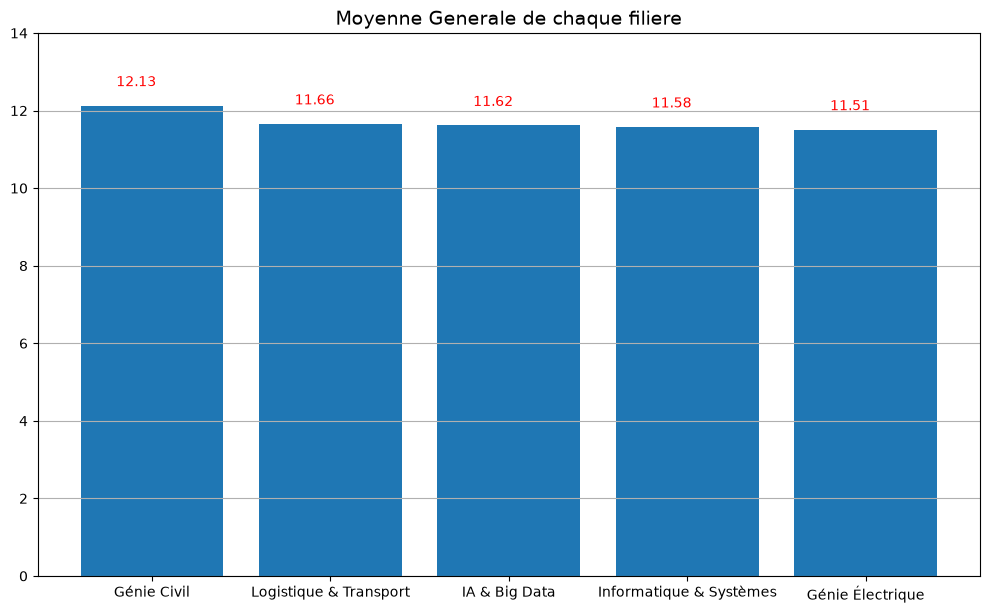

In [33]:
ax = plt.figure(figsize =(10, 6))
moy_filiere_ord = moy_filiere.sort_values("moyenne_Generale", ascending = False)
plt.bar(moy_filiere_ord["filiere"], moy_filiere_ord["moyenne_Generale"])
plt.tight_layout()
plt.ylim(0, 14)
plt.grid(axis = "y")
plt.title("Moyenne Generale de chaque filiere", size =14)

liste = moy_filiere_ord["moyenne_Generale"].tolist()
for i in range(len(liste)):
    plt.text(i- 0.2, liste[i]+0.5, liste[i], c = "red")
    
plt.xticks(rotation = 0)
plt.show()


# PARTIE 7 — TAUX DE RÉUSSITE PAR FILIÈRE

### Graphique
Comparer toutes les filières.

### Questions
1. Quelle filière possède le meilleur taux ?
2. Quelle possède le plus faible ?
3. Quelle est la différence ?
4. Les différences sont-elles importantes ?
5. Une bonne moyenne implique-t-elle forcément un bon taux de réussite ?
6. Compare avec la Partie 6.
7. Quelle filière semble globalement la plus performante ?

---


In [34]:
data.tail()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie,categorie_notes
795,ETU1138,Lawson,Kodjo,17,F,Génie Civil,L1,5.59,Tres faible,échec
796,ETU1357,Kouassi,Eyram,22,M,Génie Électrique,L1,5.21,Tres faible,échec
797,ETU1746,Tchalla,Sena,21,M,IA & Big Data,L2,5.16,Tres faible,échec
798,ETU1379,Adjei,Koffi,24,F,Génie Civil,L2,5.12,Tres faible,échec
799,ETU1541,Mensah,Ama,25,M,Informatique & Systèmes,L3,4.33,Tres faible,échec


In [35]:
cole = pd.crosstab(data["filiere"], data["categorie_notes"])
cole

categorie_notes,réussite,échec
filiere,,
Génie Civil,103,28
Génie Électrique,115,35
IA & Big Data,147,42
Informatique & Systèmes,138,62
Logistique & Transport,95,35


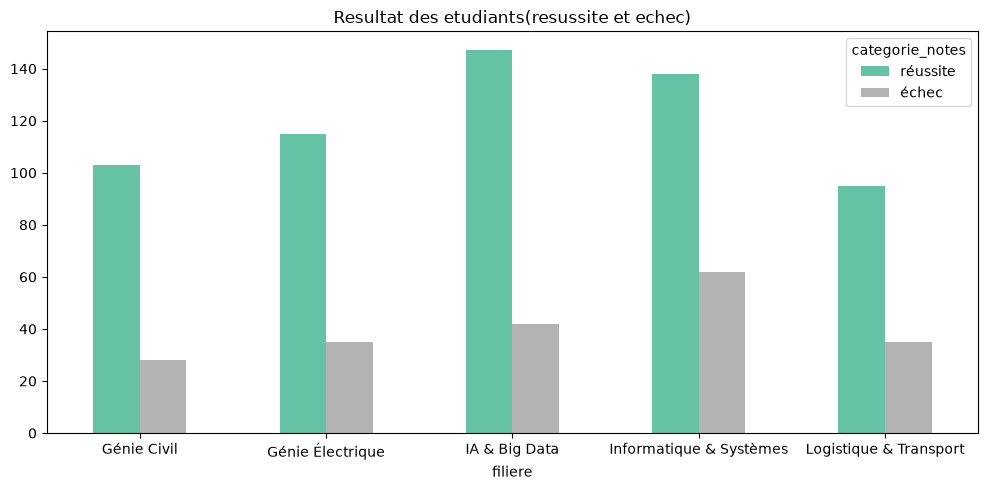

In [36]:
ax = cole.plot(kind = "bar", figsize = (10, 5), colormap = "Set2")
plt.title("Resultat des etudiants(resussite et echec)")


# for container in ax.containers:
#     for objet in container :
#         taille = objet.get_height()
#         if taille > 0:
#             x = objet.get_x() + objet.get_width()/2
#             y = taille + 2 # Petit decalage de 2% vers le haut
#             plt.text(x, y, f"{taille : .1f}%", va = "center", ha = "center", color = "red")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [37]:
attitude= pd.read_csv("../projet_pandas_universitaire/data/attendance.csv")

In [38]:
attitude.head()

,student_id,semestre,taux_presence,absences,retards
0,ETU1000,S1,88.22,6,3
1,ETU1000,S2,79.11,10,6
2,ETU1001,S1,98.29,1,2
3,ETU1001,S2,92.43,4,4
4,ETU1002,S1,77.95,11,1


<p style =
    "background : blue;padding : 10px 0 10px 0; color : white "
    >Bien je vais essayer de voir si l'echec des etudiant est lier a leur taux de retard, absenec et autre
</p> 

In [39]:
data.shape

(800, 10)

In [40]:
attitude.shape

(1600, 5)

In [41]:
attitude.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   student_id     1600 non-null   str    
 1   semestre       1600 non-null   str    
 2   taux_presence  1585 non-null   float64
 3   absences       1600 non-null   int64  
 4   retards        1600 non-null   int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 76.7 KB


In [42]:
attitude.dropna(inplace = True)

In [43]:
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie,categorie_notes
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent,réussite
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent,réussite
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent,réussite
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent,réussite
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent,réussite


In [44]:
#Fusion des deux dataset regroupant les etudiant et leur attitude

In [45]:
df = pd.merge(data[["student_id","age", "sexe", "filiere", "niveau", "moyenne_Generale"]], attitude, on = "student_id", how = "left")

In [46]:
df.head()

,student_id,age,sexe,filiere,niveau,moyenne_Generale,semestre,taux_presence,absences,retards
0,ETU1648,18,M,Génie Électrique,L1,18.64,S1,80.04,10.0,2.0
1,ETU1648,18,M,Génie Électrique,L1,18.64,S2,80.46,10.0,2.0
2,ETU1416,21,M,IA & Big Data,L1,18.48,S1,83.14,8.0,3.0
3,ETU1416,21,M,IA & Big Data,L1,18.48,S2,78.61,11.0,2.0
4,ETU1060,23,M,Logistique & Transport,L1,18.23,S1,77.06,11.0,1.0


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1586 entries, 0 to 1585
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        1586 non-null   str    
 1   age               1586 non-null   int64  
 2   sexe              1586 non-null   str    
 3   filiere           1586 non-null   str    
 4   niveau            1586 non-null   str    
 5   moyenne_Generale  1586 non-null   float64
 6   semestre          1585 non-null   str    
 7   taux_presence     1585 non-null   float64
 8   absences          1585 non-null   float64
 9   retards           1585 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 171.6 KB


In [48]:
df.isnull().sum()

student_id          0
age                 0
sexe                0
filiere             0
niveau              0
moyenne_Generale    0
semestre            1
taux_presence       1
absences            1
retards             1
dtype: int64

- Encode des variables categorielles et des features

In [49]:
var_numeric = df.select_dtypes(include = ["int64", "float64"]).columns
var_cat =  df.select_dtypes(include = 'object').columns
var_cat = var_cat[1: ]

C:\Users\dc\AppData\Local\Temp\ipykernel_4824\1568856524.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  var_cat =  df.select_dtypes(include = 'object').columns


In [50]:
print(f"- Variable numerique  : {var_numeric}\n- Variable categorielle : {var_cat}")

- Variable numerique  : Index(['age', 'moyenne_Generale', 'taux_presence', 'absences', 'retards'], dtype='str')
- Variable categorielle : Index(['sexe', 'filiere', 'niveau', 'semestre'], dtype='str')


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler

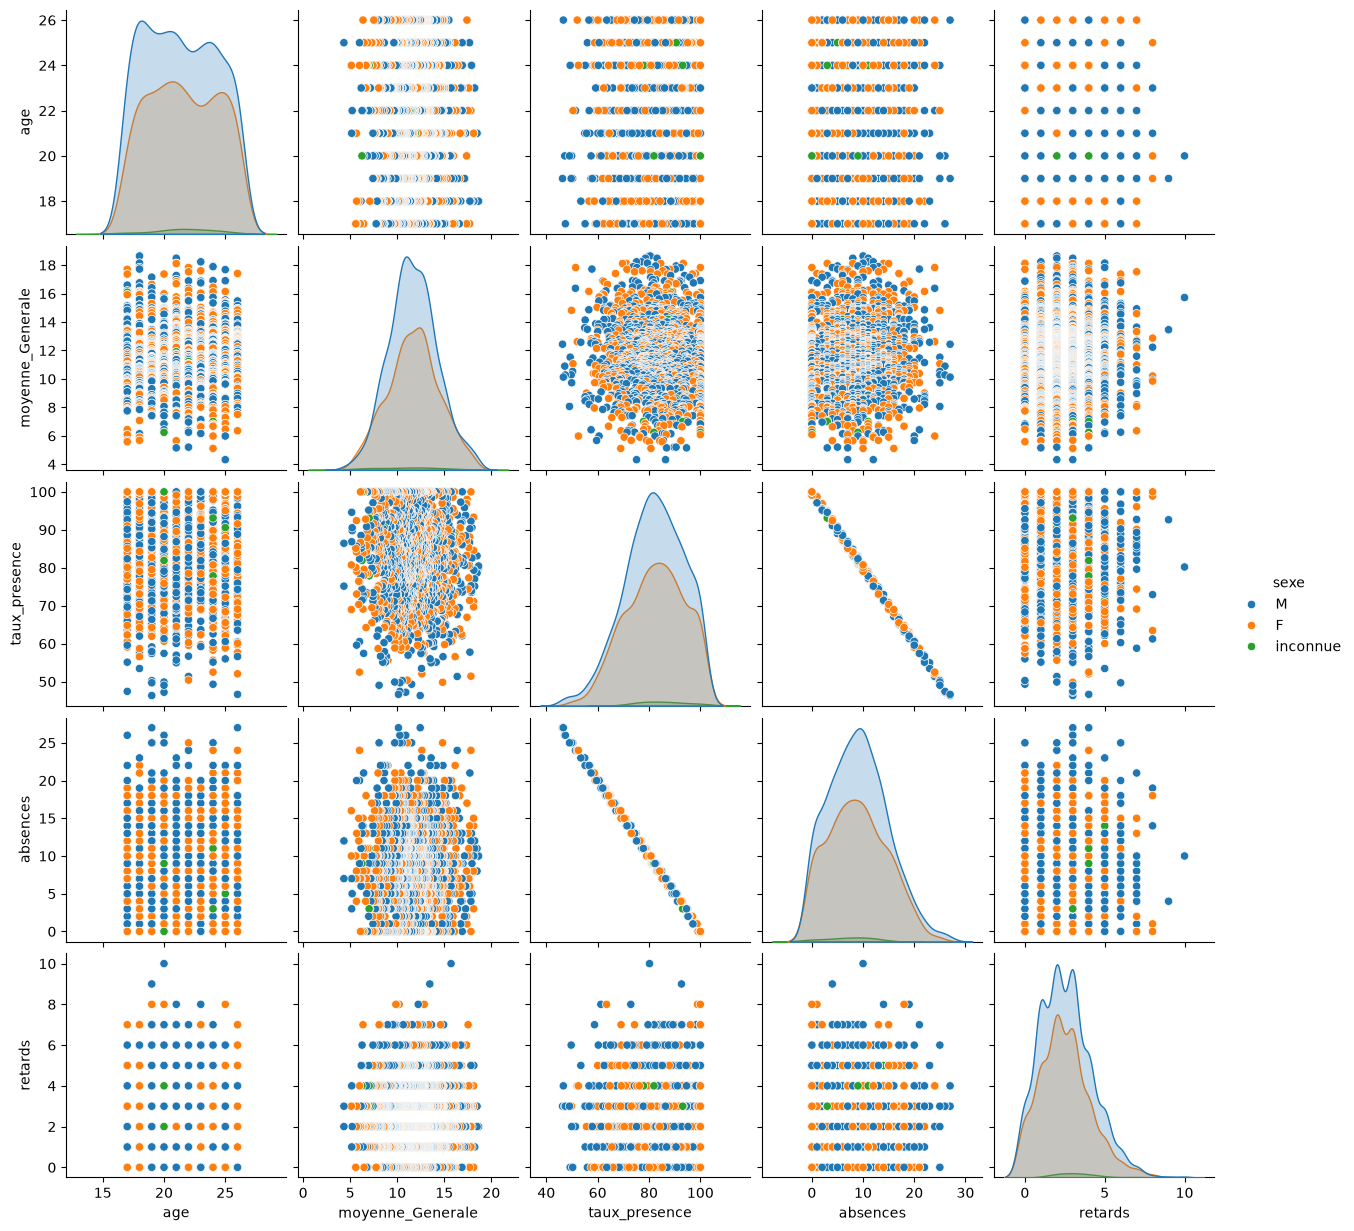

In [52]:
sns.pairplot(df, hue = 'sexe')

In [53]:
data = df
Encode = LabelEncoder()
for i in var_cat :
    data[i] = Encode.fit_transform(data[i])

In [54]:
data.head()

,student_id,age,sexe,filiere,niveau,moyenne_Generale,semestre,taux_presence,absences,retards
0,ETU1648,18,1,1,0,18.64,0,80.04,10.0,2.0
1,ETU1648,18,1,1,0,18.64,1,80.46,10.0,2.0
2,ETU1416,21,1,2,0,18.48,0,83.14,8.0,3.0
3,ETU1416,21,1,2,0,18.48,1,78.61,11.0,2.0
4,ETU1060,23,1,4,0,18.23,0,77.06,11.0,1.0


In [72]:
data.drop("student_id", axis = 1)
data.head()

,student_id,age,sexe,filiere,niveau,moyenne_Generale,semestre,taux_presence,absences,retards
0,ETU1648,18,1,1,0,18.64,0,80.04,10.0,2.0
1,ETU1648,18,1,1,0,18.64,1,80.46,10.0,2.0
2,ETU1416,21,1,2,0,18.48,0,83.14,8.0,3.0
3,ETU1416,21,1,2,0,18.48,1,78.61,11.0,2.0
4,ETU1060,23,1,4,0,18.23,0,77.06,11.0,1.0


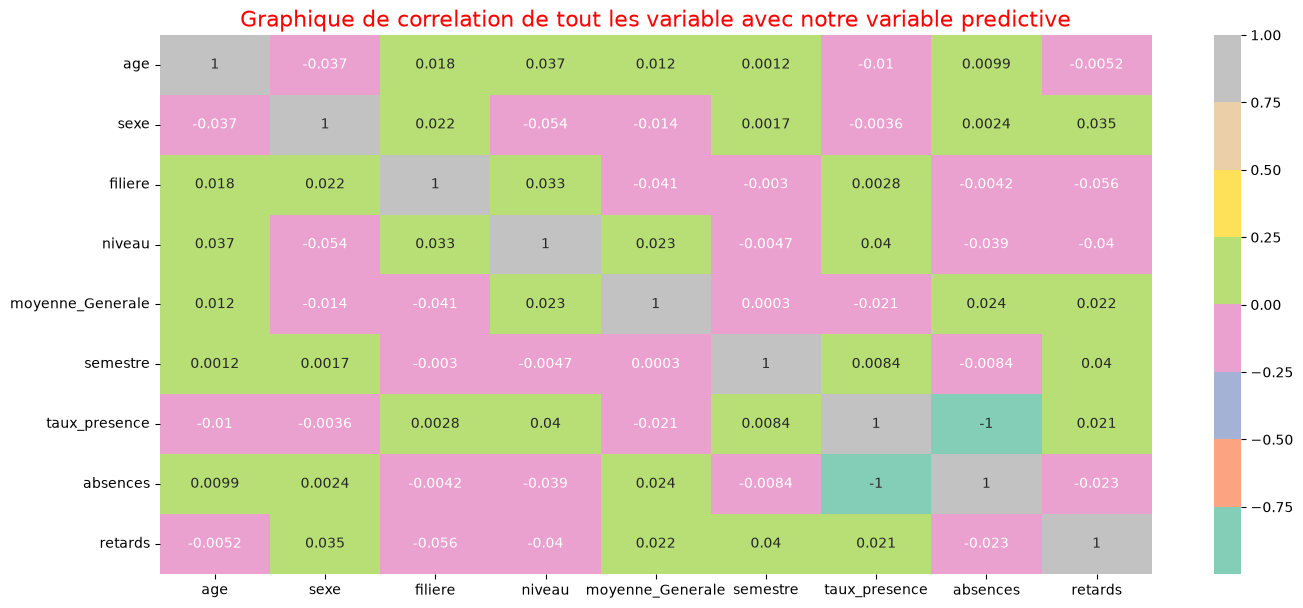

In [56]:
plt.figure(figsize = (16,7))
sns.heatmap(data.corr(numeric_only = True), annot =True, cmap = "Set2", alpha = 0.8)
plt.title("Graphique de correlation de tout les variable avec notre variable predictive", size = 16, c = "red")
plt.xticks(rotation = 0)
plt.show()

In [57]:
X = data.drop(["student_id", "moyenne_Generale"], axis = 1)
X.head()

,age,sexe,filiere,niveau,semestre,taux_presence,absences,retards
0,18,1,1,0,0,80.04,10.0,2.0
1,18,1,1,0,1,80.46,10.0,2.0
2,21,1,2,0,0,83.14,8.0,3.0
3,21,1,2,0,1,78.61,11.0,2.0
4,23,1,4,0,0,77.06,11.0,1.0


In [58]:
y = data["moyenne_Generale"]
y

0       18.64
1       18.64
2       18.48
3       18.48
4       18.23
        ...  
1581     5.16
1582     5.12
1583     5.12
1584     4.33
1585     4.33
Name: moyenne_Generale, Length: 1586, dtype: float64

In [86]:
colonne = data[["moyenne_Generale", "age", "taux_presence", "absences", "retards"]].columns.tolist()
colonne

['moyenne_Generale', 'age', 'taux_presence', 'absences', 'retards']